In [21]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
import os
from dotenv import load_dotenv

load_dotenv()

def get_chat():
    llm = HuggingFaceEndpoint(
        repo_id="meta-llama/Llama-3.1-8B-Instruct",
        huggingfacehub_api_token=os.environ["HUGGINGFACEHUB_API_TOKEN"],
        temperature=0,
    )
    return ChatHuggingFace(llm=llm)

In [22]:
#LLM for structured response generation

# template for structured output from LLM 

def structured_invoke(model, schema, user_input,template):
    parser = PydanticOutputParser(pydantic_object=schema)

    prompt=PromptTemplate(
    template="{template} in {JSON_FORMAT}.\n\n {user_input}",
    input_variables=["template","user_input"],
    partial_variables={"JSON_FORMAT":parser.get_format_instructions()})   
    
    formatted_prompt = prompt.format(template=template,user_input=user_input)
    response = model.invoke(formatted_prompt)
    return parser.parse(response.content)


In [23]:
from typing import TypedDict,Annotated,Literal
from pydantic import BaseModel,Field
from langgraph.graph import StateGraph, START, END
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import PromptTemplate
import operator

In [24]:
class FeedbackState(TypedDict):
    feedback: str
    sentiment: Literal["positive", "negative"]
    response: str
    diagnosis: dict
    

In [25]:
# Schemas for structured output from LLM 
class FeedbackSchema(BaseModel):
    sentiment: Literal["positive", "negative"] = Field(description="Sentiment of the feedback")


class DiagnosisSchema(BaseModel):
    issues: list[str] = Field(description="List of issues mentioned in the review")
    severity: str = Field(description="Severity of the issues") 
    tone: str = Field(description="Tone of the review")

In [52]:
def find_sentiment(state: FeedbackState) :
    feedback = state["feedback"].lower()
    prompt="Classify the sentiment of the feedback as positive or negative "
    chat=structured_invoke(get_chat(),FeedbackSchema,feedback,prompt)
    return {"sentiment": chat.sentiment}

def check_sentiment(state: FeedbackState) -> Literal["generate_positive_response", "run_diagnosis"]:
    sentiment = state["sentiment"]
    if sentiment == "positive":
        return "generate_positive_response"
    else:
        return "run_diagnosis"
                        

def generate_positive_response(state: FeedbackState) :
    feedback = state["feedback"]
    prompt="Generate a positive response to the following feedback: "
    chat=get_chat().invoke(prompt+feedback)
    return {"response": str(chat)}

def run_diagnosis(state: FeedbackState) :
    feedback = state["feedback"].lower()
    prompt="Analyze the following feedback and identify potential issues"
    chat=structured_invoke(get_chat(),DiagnosisSchema,feedback,prompt)
    return {"diagnosis": chat.model_dump()}

def generate_negative_response(state: FeedbackState) :
    feedback = state["feedback"]
    prompt="Generate a response to the following feedback: "
    chat=structured_invoke(get_chat(),FeedbackSchema,feedback,prompt)
    return {"response": str(chat)}

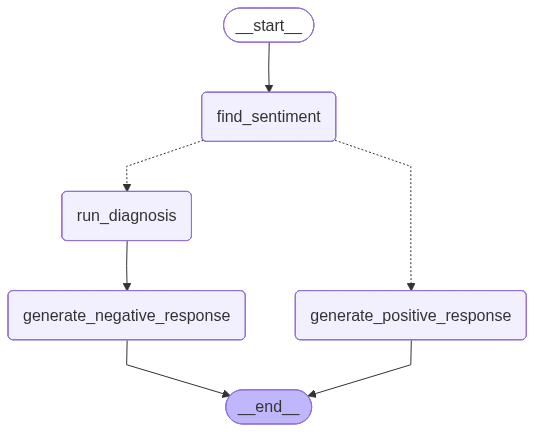

In [47]:
graph=StateGraph(FeedbackState)
graph.add_node("find_sentiment",find_sentiment)
graph.add_node("generate_positive_response",generate_positive_response)
graph.add_node("generate_negative_response",generate_negative_response)
graph.add_node("run_diagnosis"  ,run_diagnosis)

graph.add_edge(START,"find_sentiment")
graph.add_conditional_edges("find_sentiment", check_sentiment,{
    "generate_positive_response": "generate_positive_response",
    "run_diagnosis": "run_diagnosis"
})


graph.add_edge("generate_positive_response", END)
graph.add_edge("run_diagnosis", "generate_negative_response")
graph.add_edge("generate_negative_response", END)


workflow =graph.compile()
workflow



In [53]:
initial_state = {
    "feedback": "The product quality is bad and I am very sad with my purchase."
}
workflow.invoke(initial_state)

{'feedback': 'The product quality is bad and I am very sad with my purchase.',
 'sentiment': 'negative',
 'response': "sentiment='negative'",
 'diagnosis': {'issues': ['Product quality is not meeting expectations',
   'Customer is unhappy with their purchase'],
  'severity': 'Major',
  'tone': 'Negative'}}